### Generaione dei dati

In [1683]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statistics
import math

In [1684]:
def gaussian_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

In [1685]:
def covarianza(X, Y, c):
    n = len(X)
    mean_X = np.mean(X)
    mean_Y = np.mean(Y)
    cov = sum((X[i] - mean_X) * (Y[i] - mean_Y) for i in range(n)) / c
    return cov

In [1686]:
def varianza(X, c):
    n = len(X)
    mean_X = np.mean(X)
    var = sum((X[i] - mean_X) ** 2 for i in range(n)) / c
    var = np.sqrt(var)
    return var

In [1687]:
def correllazione(X, Y, c):
        var1 = varianza(X, c)
        var2 = varianza(Y, c)
        return covarianza(X, Y, c) / (var1 * var2)

In [1688]:
def Q2(X,Y,c,rho):
    Q = np.array([])
    var1=varianza(X,c)
    var2=varianza(Y,c)
    for i in range(len(X)):
        res=(1/(1-rho**2))*(((X[i] - np.mean(X))/var1)**2 + ((Y[i] - np.mean(Y))/var2)**2 - 2*rho*((X[i] - np.mean(X))/var1))
        Q = np.append(Q, res)
    return Q

In [1689]:
def varianza_correllate(X, Y, c):
    var = varianza(X, c) + varianza(Y, c) - 2 * covarianza(X, Y, c)
    var = np.sqrt(var)
    return var

In [1690]:
def sigma_condizionato(X, Y, c, rho):
    var1 = varianza(X, c)
    return np.sqrt((1 - rho**2)) * var1

In [1691]:
def mu_condizionato(X, Y, c, rho):
    var1 = varianza(X, c)
    var2 = varianza(Y, c)
    return np.mean(X) + rho * (var1 / var2) * (19.7 - np.mean(Y))


In [1692]:
def Q2_condizionato(X,Y,c,rho):
    Q = np.array([])
    sx=sigma_condizionato(X, Y, c, rho)
    sy=varianza(Y, c)
    mx=mu_condizionato(X, Y, c, rho)
    my=np.mean(Y)
    for i in range(len(X)):
        res=(1/(1-rho**2))*(((X[i] - mx)/sx)**2 + ((Y[i] - my)/sy)**2 - 
                            2*rho*(((X[i] - mx)/sx)*((Y[i] - my)/sy)))
        Q = np.append(Q, res)
    return Q

In [1693]:
N=10000
n1=np.random.normal(10,0.2,N)
n2=np.random.normal(20,0.2,N)


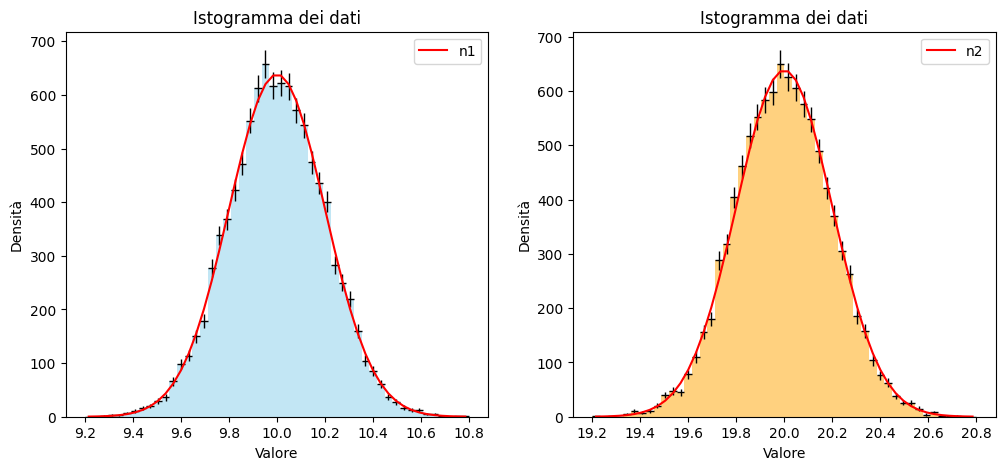

In [1694]:
#controllo che i dati siano normali
h1, bins1 = np.histogram(n1, bins=50, range=(10-4*0.2, 10+4*0.2))
centri1 = (bins1[:-1] + bins1[1:]) / 2
delta_x1 = bins1[1] - bins1[0]

h2, bins2 = np.histogram(n2, bins=50, range=(20-4*0.2, 20+4*0.2))
centri2 = (bins2[:-1] + bins2[1:]) / 2
delta_x2 = bins2[1] - bins2[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(centri1, h1, width=delta_x1, color='skyblue', alpha=0.5, label='n1')
ax1.errorbar(centri1, h1, yerr=np.sqrt(h1), xerr=delta_x1/2, fmt='none', color='black', lw=1)
ax1.plot(centri1, gaussian_pdf(centri1, 10, 0.2)*len(n1)*delta_x1, color='red', label='Normale standard')
ax1.set_title('Istogramma dei dati')
ax1.set_xlabel('Valore')
ax1.set_ylabel('Densità')
ax1.legend(['n1'])

ax2.bar(centri2, h2, width=delta_x2, color='orange', alpha=0.5, label='n2')
ax2.errorbar(centri2, h2, yerr=np.sqrt(h2), xerr=delta_x2/2, fmt='none', color='black', lw=1)
ax2.plot(centri2, gaussian_pdf(centri2, 20, 0.2)*len(n2)*delta_x2,color='red', label='Normale standard')
ax2.set_title('Istogramma dei dati')
ax2.set_xlabel('Valore')
ax2.set_ylabel('Densità')
ax2.legend(['n2'])


In [1695]:
cov = covarianza(n1, n2, N-1)
print(f"Covarianza con Bessel: {cov}")
cov = covarianza(n1, n2, N)
print(f"Covarianza baised: {cov}")

cor = correllazione(n1, n2, N-1)
print(f"Correlazione: {cor}")
cor = correllazione(n1, n2, N)
print(f"Correlazione baised: {cor}")

var_n1 = varianza(n1, N-1)
print(f"Varianza di n1 con Bessel: {var_n1}")
var_n1 = varianza(n1, N)
print(f"Varianza di n1 baised: {var_n1}")

var_n2 = varianza(n2, N-1)
print(f"Varianza di n2 con Bessel: {var_n2}")
var_n2 = varianza(n2, N)
print(f"Varianza di n2 baised: {var_n2}")


Covarianza con Bessel: 0.00016483627312496274
Covarianza baised: 0.00016481978949765025
Correlazione: 0.004114353451901904
Correlazione baised: 0.004114353451901904
Varianza di n1 con Bessel: 0.20087949380154752
Varianza di n1 baised: 0.2008694495757455
Varianza di n2 con Bessel: 0.1994415237354058
Varianza di n2 baised: 0.19943155140990465


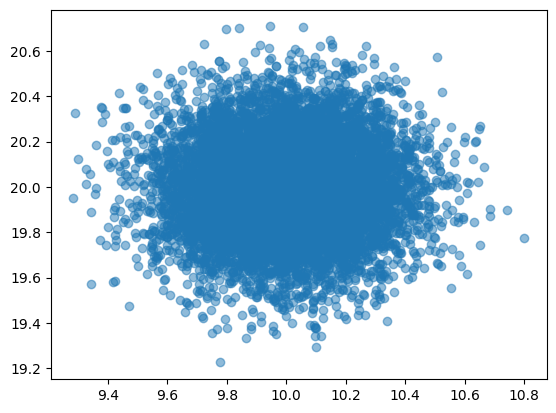

In [1696]:
plt.scatter(n1, n2, alpha=0.5)

Numero di punti dentro l'ellisse: 3927


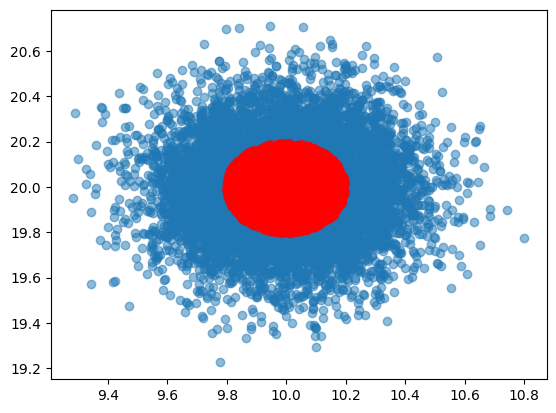

Rapporto fra punti e coppie: 0.3927


In [1697]:
Q = Q2(n1, n2, N-1, 0)
punti_ellisse = np.where(Q <= 1)
plt.scatter(n1[punti_ellisse], n2[punti_ellisse], color='red', alpha=0.5, label='Punti dentro l\'ellisse')
print(f"Numero di punti dentro l'ellisse: {len(punti_ellisse[0])}")
plt.scatter(n1, n2, alpha=0.5)
plt.scatter(n1[punti_ellisse], n2[punti_ellisse], color='red', alpha=0.5, label='Punti dentro l\'ellisse')
plt.show()
print(f"Rapporto fra punti e coppie: {len(punti_ellisse[0])/N}")

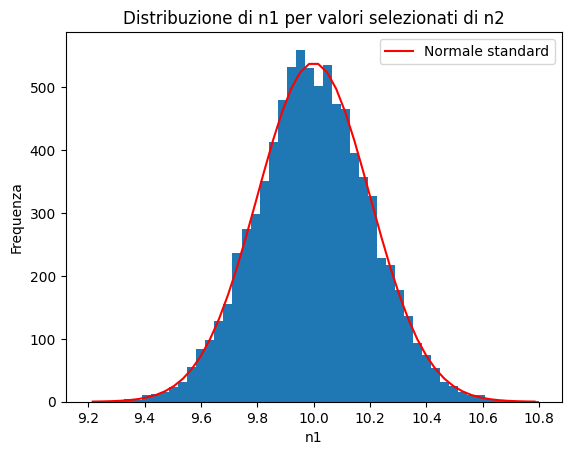

In [1698]:
punti_selezionati= np.where((n2 >= 19.2) & (n2 <= 20.2))

h1, bins1, patches = plt.hist(n1[punti_selezionati], bins=50, range=(10-4*0.2, 10+4*0.2))
centri1 = (bins1[:-1] + bins1[1:]) / 2
delta_x1 = bins1[1] - bins1[0]
plt.plot(centri1, gaussian_pdf(centri1, 10, 0.2)*len(n1[punti_selezionati])*delta_x1, color='red', label='Normale standard')
plt.xlabel('n1')
plt.ylabel('Frequenza')
plt.title('Distribuzione di n1 per valori selezionati di n2')
plt.legend()
plt.show()

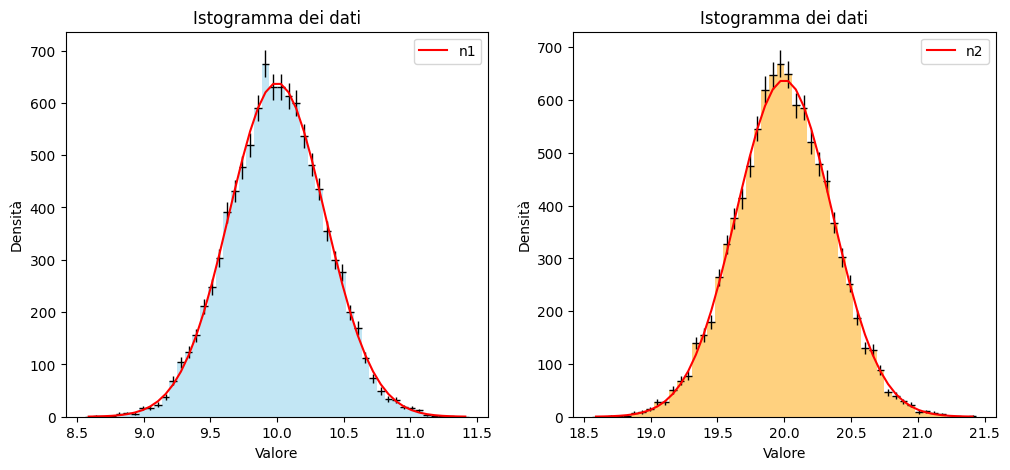

In [1699]:
s=np.random.normal(0,0.3,N)
n1=n1+s
n2=n2+s

var_n1 = varianza(n1, N-1)
var_n2 = varianza(n2, N-1)

#controllo che i dati siano normali
h1, bins1 = np.histogram(n1, bins=50, range=(10-4*var_n1, 10+4*var_n1))
centri1 = (bins1[:-1] + bins1[1:]) / 2
delta_x1 = bins1[1] - bins1[0]

h2, bins2 = np.histogram(n2, bins=50, range=(20-4*var_n2, 20+4*var_n2))
centri2 = (bins2[:-1] + bins2[1:]) / 2
delta_x2 = bins2[1] - bins2[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


ax1.bar(centri1, h1, width=delta_x1, color='skyblue', alpha=0.5, label='n1')
ax1.errorbar(centri1, h1, yerr=np.sqrt(h1), xerr=delta_x1/2, fmt='none', color='black', lw=1)
ax1.plot(centri1, gaussian_pdf(centri1, 10, var_n1)*len(n1)*delta_x1, color='red', label='Normale standard')
ax1.set_title('Istogramma dei dati')
ax1.set_xlabel('Valore')
ax1.set_ylabel('Densità')
ax1.legend(['n1'])

ax2.bar(centri2, h2, width=delta_x2, color='orange', alpha=0.5, label='n2')
ax2.errorbar(centri2, h2, yerr=np.sqrt(h2), xerr=delta_x2/2, fmt='none', color='black', lw=1)
ax2.plot(centri2, gaussian_pdf(centri2, 20, var_n2)*len(n2)*delta_x2,color='red', label='Normale standard')
ax2.set_title('Istogramma dei dati')
ax2.set_xlabel('Valore')
ax2.set_ylabel('Densità')
ax2.legend(['n2'])

In [1700]:
var_n1 = varianza(n1, N-1)
print(f"Varianza di n1 con Bessel: {var_n1}")
var_n1 = varianza(n1, N)
print(f"Varianza di n1 baised: {var_n1}")  
var_n2 = varianza(n2, N-1)
print(f"Varianza di n2 con Bessel: {var_n2}")  
var_n2 = varianza(n2, N)
print(f"Varianza di n2 baised: {var_n2}")
corr = correllazione(n1, n2, N-1) 
print(f"Correlazione: {corr}")
var_correllate = varianza_correllate(n1, n2, N-1)
print(f"Varianza delle variabili correllate: {var_correllate}")
var_z=varianza(n1+n2, N-1)
print(f"Varianza di Z: {var_z}")

Varianza di n1 con Bessel: 0.36089755460886946
Varianza di n1 baised: 0.3608795092799945
Varianza di n2 con Bessel: 0.3596054413745282
Varianza di n2 baised: 0.3595874606529302
Correlazione: 0.6925654765912953
Varianza delle variabili correllate: 0.735350050974489
Varianza di Z: 0.6628170312416879


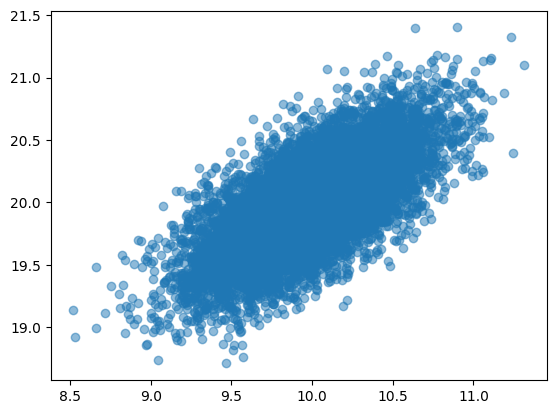

In [1701]:
plt.scatter(n1, n2, alpha=0.5)

Numero di punti dentro l'ellisse: 2290


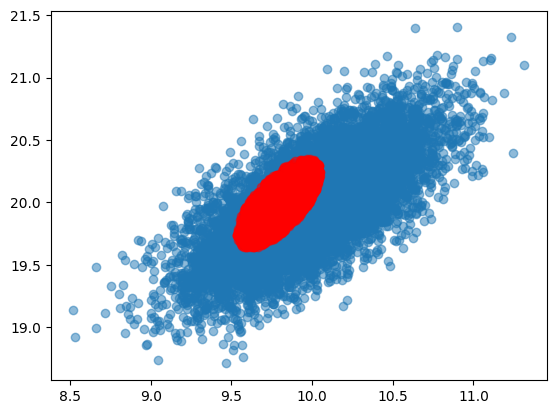

Rapporto fra punti e coppie: 0.229


In [1702]:
Q = Q2_condizionato(n1, n2, N-1, corr)
punti_ellisse = np.where(Q <= 1)
plt.scatter(n1[punti_ellisse], n2[punti_ellisse], color='red', alpha=0.5, label='Punti dentro l\'ellisse')
print(f"Numero di punti dentro l'ellisse: {len(punti_ellisse[0])}")
plt.scatter(n1, n2, alpha=0.5)
plt.scatter(n1[punti_ellisse], n2[punti_ellisse], color='red', alpha=0.5, label='Punti dentro l\'ellisse')
plt.show()
print(f"Rapporto fra punti e coppie: {len(punti_ellisse[0])/N}")

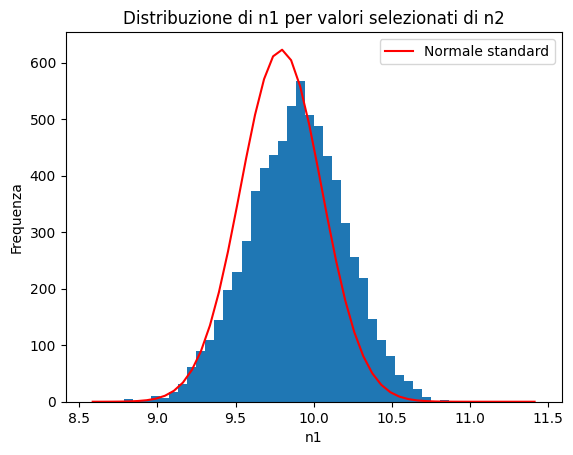

In [ ]:
punti_selezionati= np.where((n2 >= 19.2) & (n2 <= 20.2))
h1, bins1, patches = plt.hist(n1[punti_selezionati], bins=50, range=(10-4*var_n1, 10+4*var_n1))
centri1 = (bins1[:-1] + bins1[1:]) / 2
delta_x1 = bins1[1] - bins1[0]

plt.plot(centri1, gaussian_pdf(centri1, mu_condizionato(n1, n2, N-1, corr), sigma_condizionato(n1,
                         n2, N-1, corr))*len(n1[punti_selezionati])*delta_x1, color='red', label='Normale standard')
plt.xlabel('n1')
plt.ylabel('Frequenza')
plt.title('Distribuzione di n1 per valori selezionati di n2')
plt.legend()
plt.show()
